# Model Demo

This demo shows how the trained YOLO11 model loads, processes meal images, and returns food component detections with labels and confidence scores.

## 1. Install Ultralytics

The Ultralytics package is installed to provide access to the YOLO11 model and prediction tools.

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.3 MB/s eta 0:00:00


## 2. Load the Trained Model

The trained `best.pt` file is loaded as a YOLO11 model for food component detection.

In [2]:
from ultralytics import YOLO

model = YOLO("/content/best.pt")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 3. Verify the Model

The model is checked to confirm that it loaded correctly and contains the 10 food component classes.

In [3]:
print("Model loaded successfully!")
print(model.names)

Model loaded successfully!
{0: 'bread', 1: 'rice', 2: 'potato', 3: 'egg', 4: 'cheese', 5: 'tomato', 6: 'carrot', 7: 'cucumber', 8: 'salad', 9: 'fruit'}


## 4. Run Inference

The model analyzes the meal image using a confidence threshold of 0.25 and saves the annotated prediction.

In [17]:
results = model.predict(
    source="/content/13.jpeg",
    conf=0.25,
    save=True
)


image 1/1 /content/13.jpeg: 640x544 1 bread, 1 egg, 1 tomato, 1 salad, 191.4ms
Speed: 4.2ms preprocess, 191.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 544)
Results saved to /content/runs/detect/predict


## 5. Run Inference on a Successful Example

The model correctly identifies salad, tomato, and egg with relatively strong confidence scores. It also predicts bread with lower confidence, showing that some visually similar food components may still be confused.

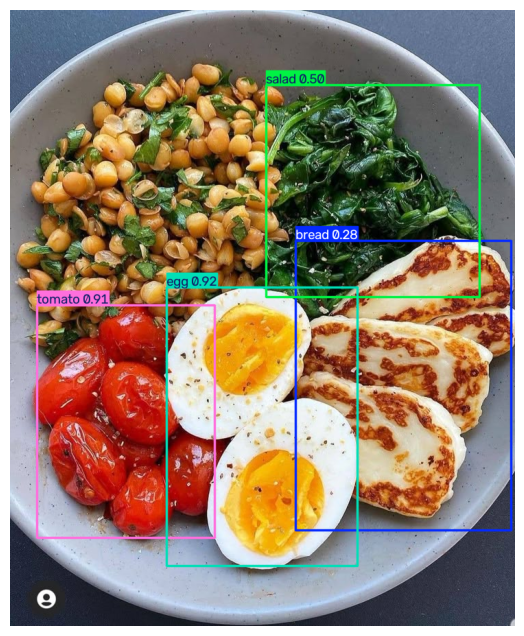

In [18]:
from matplotlib import pyplot as plt

annotated = results[0].plot()
plt.figure(figsize=(8, 8))
plt.imshow(annotated[..., ::-1])
plt.axis("off")
plt.show()

## 6. Model Limitation

The model correctly identifies cucumber, but misclassifies tuna as rice with high confidence (0.76) and does not detect the egg.

In [7]:
results_2 = model.predict(
    source="/content/12.jpeg",
    conf=0.25,
    save=True
)


image 1/1 /content/12.jpeg: 640x448 1 rice, 1 cucumber, 170.2ms
Speed: 3.3ms preprocess, 170.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/detect/predict


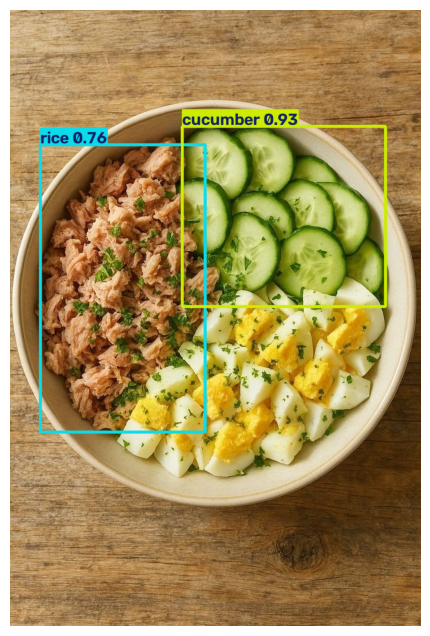

In [8]:
from matplotlib import pyplot as plt

annotated_2 = results_2[0].plot()
plt.figure(figsize=(8, 8))
plt.imshow(annotated_2[..., ::-1])
plt.axis("off")
plt.show()